# TD Learning

Following **Chapter 6** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [40]:
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

### SARSA (on-policy TD control) - Windy Gridworld

Page *131*. Exercises *6.9* and *6.10*

In [41]:
class WindyGridWorldEnv:

    def __init__(self, 
            grid_shape: tuple[int, int], 
            goal_position: tuple[int, int],
            start_position: tuple[int, int],
            wind_per_column: list[int],
            stochastic_wind: bool
            ):
        self.num_rows, self.num_cols = grid_shape[0], grid_shape[1]
        self.start_position = start_position
        self.goal_position = goal_position
        self.wind_per_column = wind_per_column
        self.stochastic_wind = stochastic_wind

        self.s = self.start_position

    def reset(self) -> tuple[int, int]:
        self.s = self.start_position
        return self.s

    def _apply_stochastic_wind(self, col: int):
        wind = self.wind_per_column[col]
        p = np.random.random()
        if p <= 1/3:
            wind -= 1
        elif p >= 2/3:
            wind += 1
        return -wind # negative - moving 'up' is a decrease in row

    def step(self, a: tuple[int, int]) -> tuple[float, tuple[int, int], bool]:

        reward = -1.0

        old_row = int(self.s[0])
        old_col = int(self.s[1])
        wind = self._apply_stochastic_wind(old_col) if self.stochastic_wind else -self.wind_per_column[old_col]

        h_move = a[1]
        v_move = a[0] + wind

        new_row = max(min(old_row + v_move, self.num_rows - 1), 0)
        new_col = max(min(old_col + h_move, self.num_cols - 1), 0)

        s_prime = (new_row, new_col)
        self.s = s_prime

        finished = s_prime == self.goal_position
        return reward, s_prime, finished


In [42]:
def plot_training_metrics(
    episode_lengths,
    episode_returns,
    smoothing_window=10
):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Episode length
    ax[0].plot(episode_lengths, alpha=0.4)

    if len(episode_lengths) >= smoothing_window:
        smoothed = np.convolve(
            episode_lengths,
            np.ones(smoothing_window) / smoothing_window,
            mode="valid"
        )
        ax[0].plot(
            range(smoothing_window - 1, len(episode_lengths)),
            smoothed,
            linewidth=2
        )

    ax[0].set_title("Episode Length")
    ax[0].set_xlabel("Episode")
    ax[0].set_ylabel("Steps to Goal")

    # Returns
    ax[1].plot(episode_returns, alpha=0.4)

    if len(episode_returns) >= smoothing_window:
        smoothed = np.convolve(
            episode_returns,
            np.ones(smoothing_window) / smoothing_window,
            mode="valid"
        )
        ax[1].plot(
            range(smoothing_window - 1, len(episode_returns)),
            smoothed,
            linewidth=2
        )

    ax[1].set_title("Episode Return")
    ax[1].set_xlabel("Episode")
    ax[1].set_ylabel("Return")

    plt.tight_layout()
    plt.show()


def plot_time_steps_per_episode(episode_lengths):
    cumulative_steps = np.cumsum(episode_lengths)
    plt.figure(figsize=(8, 5))
    plt.plot(cumulative_steps, np.arange(len(episode_lengths)))
    plt.xlabel("Time Steps")
    plt.ylabel("Episodes")
    plt.title("Windy Gridworld Learning Curve")
    plt.grid(True)
    plt.show()


def plot_policy(env, Q_pi, action_set):

    fig, ax = plt.subplots(figsize=(16, 8))
    fig.dpi = 120

    # ------------------------------------------------------------------
    # Grid geometry
    # ------------------------------------------------------------------

    ax.set_xlim(-0.5, env.num_cols - 0.5)
    ax.set_ylim(env.num_rows - 0.5, -0.5)

    ax.set_aspect("equal")

    # Major ticks = cell centers
    ax.set_xticks(np.arange(env.num_cols))
    ax.set_yticks(np.arange(env.num_rows))

    # Minor ticks = cell boundaries
    ax.set_xticks(np.arange(-0.5, env.num_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.num_rows, 1), minor=True)

    ax.grid(which="minor", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ------------------------------------------------------------------
    # Build quiver vectors
    # ------------------------------------------------------------------

    X = []
    Y = []
    U = []
    V = []

    for row in range(env.num_rows):
        for col in range(env.num_cols):

            s = (row, col)

            if s == env.goal_position:
                continue

            best_action_idx = np.argmax(Q_pi[s])
            d_row, d_col = action_set[best_action_idx]

            X.append(col)
            Y.append(row)

            # Quiver uses Cartesian coordinates:
            # +x right
            # +y up
            #
            # Gridworld rows increase downward,
            # so flip vertical direction.
            U.append(d_col)
            V.append(-d_row)

    ax.quiver(
        X,
        Y,
        U,
        V,
        angles="xy",
        scale_units="xy",
        scale=3.0,
        pivot="middle"
    )

    # ------------------------------------------------------------------
    # Start / Goal markers
    # ------------------------------------------------------------------

    start_row, start_col = env.start_position
    goal_row, goal_col = env.goal_position

    ax.scatter(
        start_col,
        start_row,
        marker="s",
        s=250,
        label="Start"
    )

    ax.scatter(
        goal_col,
        goal_row,
        marker="*",
        s=350,
        label="Goal"
    )

    # ------------------------------------------------------------------
    # Wind annotation
    # ------------------------------------------------------------------

    for col, wind in enumerate(env.wind_per_column):

        ax.text(
            col,
            -0.8,
            f"{wind}",
            ha="center",
            va="center",
            fontsize=10
        )

    ax.text(
        env.num_cols / 2,
        -1.3,
        "Wind Strength",
        ha="center",
        fontsize=12
    )

    # ------------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------------

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title("Greedy Policy Learned by SARSA")

    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

In [43]:
def initialize_Q_pi(env: WindyGridWorldEnv, actions: list[tuple[int, int]]):
    Q = {}
    for row in range(env.num_rows):
        for col in range(env.num_cols):
            s = (row, col)
            if s == env.goal_position:
                Q[s] = np.zeros(len(actions)) # zeros Q(terminal, all_a)
                continue
            Q[s] = -np.random.random(len(actions)) # arbitrary Q(s, a)
    return Q

def pi_epsilon_greedy(s: tuple[int, int], Q_pi: dict, epsilon: float) -> int:
    p = np.random.random()
    if p <= epsilon: # explore
        return int(np.random.randint(len(Q_pi[s])))
    return int(np.argmax(Q_pi[s]))

In [44]:
actions = [
    (-1, -1), (-1, 0), (-1, 1), # up-left, straight-top, up-right
    (0, -1), (0, 0), (0, 1), # straight-left, stay, straight-right
    (1, -1), (1, 0), (1, 1), # down-left, straight-down, down-right
]
actions_without_stay = actions[:4] + actions[5:] # excludes (0, 0)

grid_shape = (7, 10)
goal_position = (3, 7)
start_position = (3, 0)
wind_per_column = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

In [53]:
gamma = 0.9 # discount factor
alpha = 0.5 # step size
epsilon = 0.1 # exploration threshold
n_episodes = 200
use_stay_action = False

action_set = actions if use_stay_action else actions_without_stay
env = WindyGridWorldEnv(grid_shape, goal_position, start_position, wind_per_column, stochastic_wind=False)
Q_pi = initialize_Q_pi(env, action_set)

episode_lengths = []
episode_returns = []
for ep_idx in tqdm(range(n_episodes), desc="Episodes"): # episode loop
    s = env.reset()
    steps = 0
    G = 0.0
    while True: # steps loop
        # choose action according to behaviour policy
        a_idx = pi_epsilon_greedy(s, Q_pi, epsilon) 
        a = action_set[a_idx]
        
        # take action - single step
        r, s_prime, done = env.step(a)
        steps += 1
        G += r

        # choose the action one would take in s_prime according to behaviour policy
        a_prime_idx = pi_epsilon_greedy(s_prime, Q_pi, epsilon)

        # ----

        # Choose SARSA target
        if done: # terminal states do not bootstrap - just use reward
            target = r 
        else: # non-terminal states bootstrap
            a_prime_idx = pi_epsilon_greedy(s_prime, Q_pi, epsilon)
            target = r + gamma * Q_pi[s_prime][a_prime_idx]
        # SARSA update
        Q_pi[s][a_idx] += alpha * (target - Q_pi[s][a_idx])

        # Housekeeping
        s = s_prime
        if done:
            break
        
    episode_lengths.append(steps)
    episode_returns.append(G)

Episodes: 100%|██████████| 200/200 [00:00<00:00, 3071.24it/s]


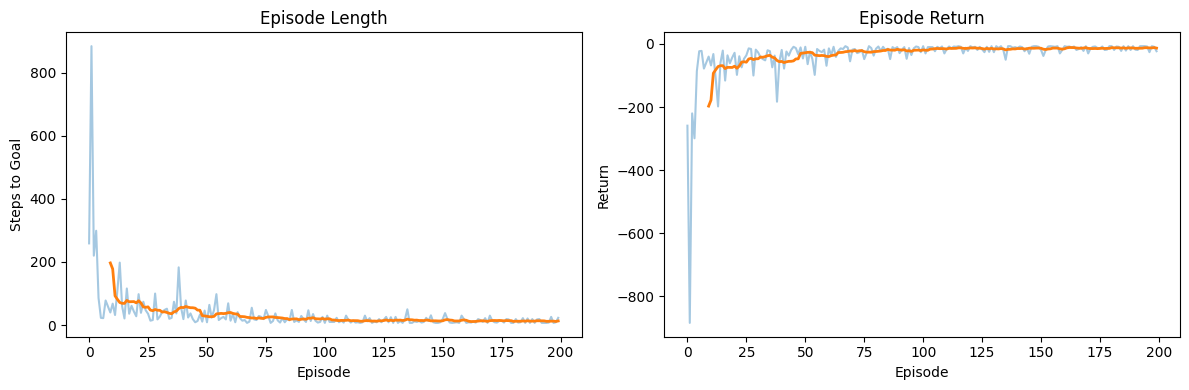

In [54]:
plot_training_metrics(episode_lengths, episode_returns)

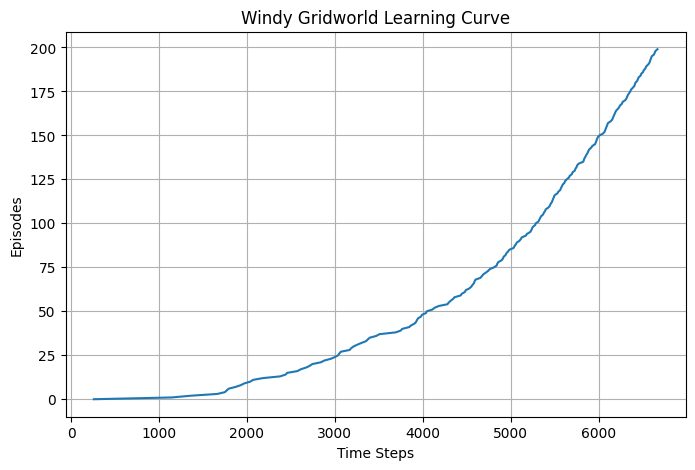

In [55]:
plot_time_steps_per_episode(episode_lengths)

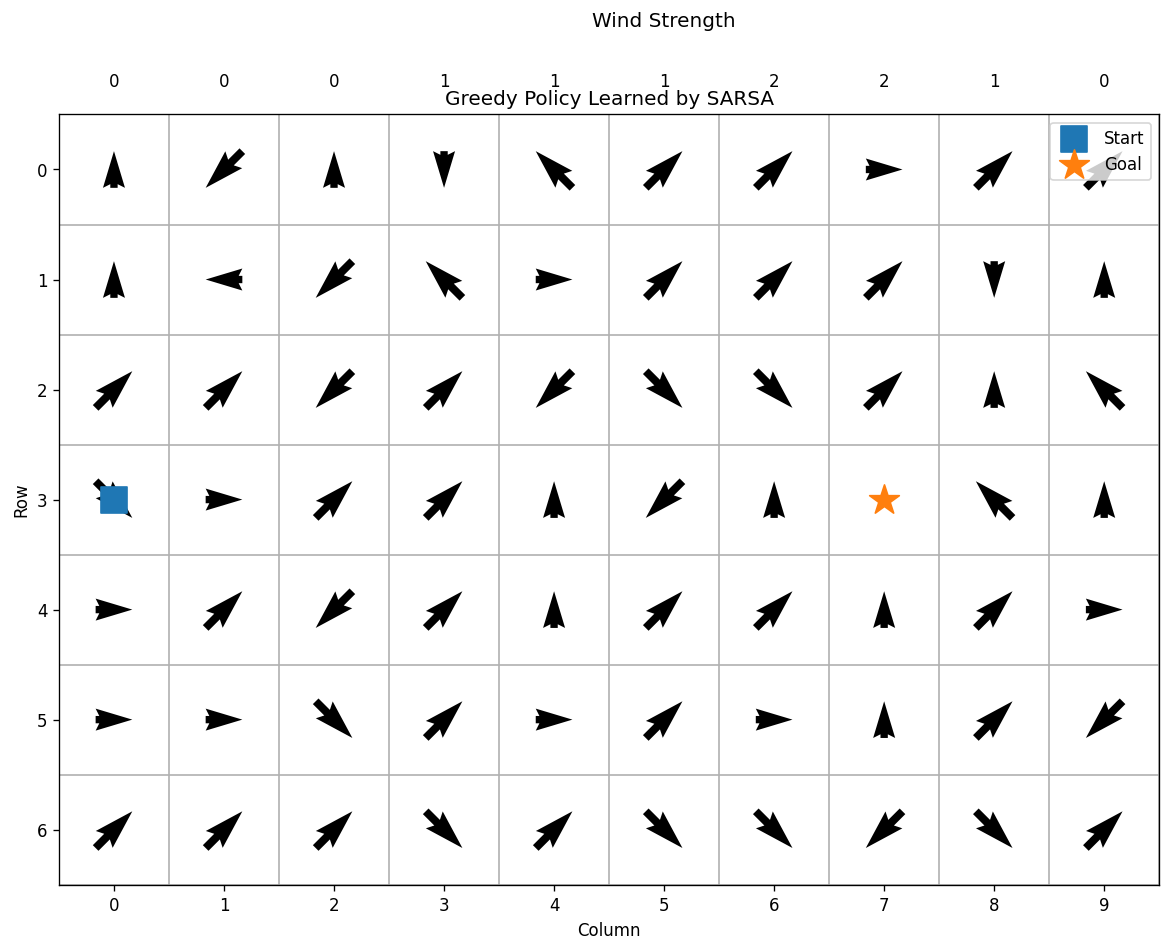

In [56]:
plot_policy(env, Q_pi, action_set)